# 01-The Physics of Agentic Workflows

In Section 13, we built the "Memory" of an Enterprise AI system. We engineered Vector Databases, Hybrid Search, and GraphRAG to ensure the LLM had access to deterministic facts.

However, a retrieval pipeline is structurally passive. It waits for a user prompt, retrieves documents, writes a summary, and immediately halts. This is a linear pipeline.

If a user asks a complex, multi-step question: *"Find the Q3 revenue in the database, calculate the tax deficit using the internal API, and if the deficit is over $10k, draft an email to the CFO."* A linear RAG pipeline mathematically collapses. It cannot conditionally branch, it cannot use calculators, and it cannot verify its own mistakes.

To cross the threshold into Artificial General Intelligence (AGI) architectures, we must transition from linear pipelines to **Autonomous Agents**. We must give the "Prefrontal Cortex" of the LLM control over a **Cyclic State Machine**.

Let's set up our environment to engineer the physics of Agentic Workflows.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import networkx as nx
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Agentic Workflow Environment Ready.")

/root/micromamba/envs/ds/lib/python3.11/site-packages/networkx/utils/backends.py:102: RuntimeWarning: networkx backend name is not a valid identifier: 'nx-loopback'. Ignoring.
  backends = _get_backends("networkx.backends")


✅ Systems Architecture & Agentic Workflow Environment Ready.


# 1. Directed Acyclic Graphs (DAGs) vs. Cyclic State Machines

To understand Agents, we must strictly define their computational graphs.

### The Linear Chain (Directed Acyclic Graph)

Standard LLM applications (like LangChain's `SequentialChain`) operate as **Directed Acyclic Graphs (DAGs)**.
Let $V$ be a set of operational nodes (Prompt, LLM, Output Parser) and $E$ be the directional edges representing data flow. In a DAG, if you trace the path of execution, you can never return to a node you have already visited.

The mathematics resolve as pure function composition:


$$y = f_3(f_2(f_1(x)))$$


The pipeline is entirely predictable, finite, and blind to errors. If $f_2$ fails, the pipeline crashes.

### The Agentic Workflow (Cyclic State Machine)

An Agent is a Turing-complete **`while` loop** driven by probability.
Instead of hardcoding the sequence of operations, we pass a set of Tools $T = \{t_1, t_2, \dots, t_n\}$ to the LLM and let the neural network act as the routing engine.

Let $s_t$ be the "State" (the running chat history) at time $t$. The LLM policy $\pi_\theta$ generates an action $a_t$:


$$a_t \sim \pi_\theta(a_t | s_t)$$

If $a_t$ is a Tool Execution (e.g., "Search Database"), the environment executes the tool and returns an Observation $o_t$. The State is updated:


$$s_{t+1} = s_t \cup \{a_t, o_t\}$$

The cycle repeats infinitely until the LLM's policy network explicitly outputs the terminal action $a_t = \text{FINISH}$. This allows the system to make a mistake, read the error message ($o_t$), and autonomously try again ($a_{t+1}$).

# 2. The ReAct (Reason + Act) Paradigm

If you simply tell an LLM to "use tools," it will violently guess function parameters, often crashing the system. In 2022, researchers at Princeton introduced the **ReAct** paradigm, proving that forcing an LLM to generate an internal "Thought" before generating an "Action" vastly increases its success rate.

The ReAct loop operates in three strict, non-negotiable phases:

1. **Thought**: The LLM mathematically plans its next move. *"I need to find the Q3 revenue. I will use the SQL Search Tool."*
2. **Action**: The LLM outputs a strictly formatted JSON command to execute a function.
3. **Observation**: The Python environment executes the function and appends the raw text result back into the prompt.

# 3. Architecting the ReAct Loop

Let's build a deterministic simulation of a raw ReAct loop from scratch in Python. We will define an environment with external tools, and simulate an LLM autonomously navigating a multi-step mathematical problem.

In [2]:
# --- 🧠 The ReAct (Reason + Act) Engine ---

class MockEnvironment:
    """Simulates the external world where tools are executed."""
    def execute_tool(self, tool_name: str, query: str) -> str:
        print(f"   ⚙️ [ENVIRONMENT] Executing Tool: {tool_name}('{query}')")
        if tool_name == "Search_Database":
            return "Q3 Revenue was $45,000."
        elif tool_name == "Calculate":
            # Safely evaluate simple math strings
            try:
                return str(eval(query))
            except:
                return "Error: Invalid Math Equation."
        return "Error: Tool Not Found."

class MockReActAgent:
    """Simulates the LLM policy generating Thoughts and Actions based on State."""
    def __init__(self):
        self.step_counter = 0

    def generate_next_node(self, state: list) -> dict:
        """Simulates the autoregressive output of the LLM."""
        self.step_counter += 1
        
        # Step 1: The agent realizes it needs data it doesn't have.
        if self.step_counter == 1:
            return {
                "Thought": "I need to find the Q3 revenue before I can calculate the tax.",
                "Action": "Search_Database",
                "Action_Input": "Q3 Revenue"
            }
        # Step 2: The agent reads the observation and realizes it needs to do math.
        elif self.step_counter == 2:
            return {
                "Thought": "The Q3 revenue is $45,000. The tax rate is 20%. I need to multiply 45000 by 0.20.",
                "Action": "Calculate",
                "Action_Input": "45000 * 0.20"
            }
        # Step 3: The agent has the final answer and terminates the loop.
        else:
            return {
                "Thought": "The tax deficit is 9000. I have enough information to answer the user.",
                "Action": "FINISH",
                "Action_Input": "The calculated tax deficit for Q3 is $9,000."
            }

# 1. Initialize the Physics Engine
agent = MockReActAgent()
env = MockEnvironment()

# 2. The Initial State (User Prompt)
state = ["User: Calculate the 20% tax deficit for the Q3 revenue."]
print(f"--- 🚀 Initiating Autonomous ReAct Loop ---")
print(state[0])

# 3. The Cyclic `while` Loop (The core of Agentic Workflows)
max_iterations = 5
iteration = 0

while iteration < max_iterations:
    iteration += 1
    print(f"\n[Loop Iteration {iteration}]")
    
    # A. The LLM processes the State and generates Thought + Action
    llm_output = agent.generate_next_node(state)
    print(f"🤔 [THOUGHT] {llm_output['Thought']}")
    
    # B. Check for Termination Signal
    if llm_output['Action'] == "FINISH":
        print(f"✅ [FINAL ANSWER] {llm_output['Action_Input']}")
        break
        
    # C. The Environment executes the Action and returns the Observation
    print(f"🛠️ [ACTION] Call `{llm_output['Action']}` with input: '{llm_output['Action_Input']}'")
    observation = env.execute_tool(llm_output['Action'], llm_output['Action_Input'])
    print(f"👁️ [OBSERVATION] {observation}")
    
    # D. Mutate the State
    state.append(f"Thought: {llm_output['Thought']}")
    state.append(f"Action: {llm_output['Action']} -> {observation}")

print("\n--- 💡 Engineering Insight ---")
print("Notice that the Python script never hardcoded the order of operations. The 'while' loop simply acts as an infinite engine. The LLM itself acted as the routing logic, deciding to Search first, Calculate second, and Finish third. If the Calculate tool had returned a Python 'SyntaxError', the LLM would have read the error in the Observation, and generated a new Thought to fix the math formatting in Iteration 3!")

--- 🚀 Initiating Autonomous ReAct Loop ---
User: Calculate the 20% tax deficit for the Q3 revenue.

[Loop Iteration 1]
🤔 [THOUGHT] I need to find the Q3 revenue before I can calculate the tax.
🛠️ [ACTION] Call `Search_Database` with input: 'Q3 Revenue'
   ⚙️ [ENVIRONMENT] Executing Tool: Search_Database('Q3 Revenue')
👁️ [OBSERVATION] Q3 Revenue was $45,000.

[Loop Iteration 2]
🤔 [THOUGHT] The Q3 revenue is $45,000. The tax rate is 20%. I need to multiply 45000 by 0.20.
🛠️ [ACTION] Call `Calculate` with input: '45000 * 0.20'
   ⚙️ [ENVIRONMENT] Executing Tool: Calculate('45000 * 0.20')
👁️ [OBSERVATION] 9000.0

[Loop Iteration 3]
🤔 [THOUGHT] The tax deficit is 9000. I have enough information to answer the user.
✅ [FINAL ANSWER] The calculated tax deficit for Q3 is $9,000.

--- 💡 Engineering Insight ---
Notice that the Python script never hardcoded the order of operations. The 'while' loop simply acts as an infinite engine. The LLM itself acted as the routing logic, deciding to Search fir

# 4. Visualizing the Unrolled Recurrent Graph

To fully grasp the difference between a linear chain and an agent, we must view the agent not as a static architecture, but as an **Unrolled Graph over Time**. We will map the exact execution nodes of the simulation we just ran.

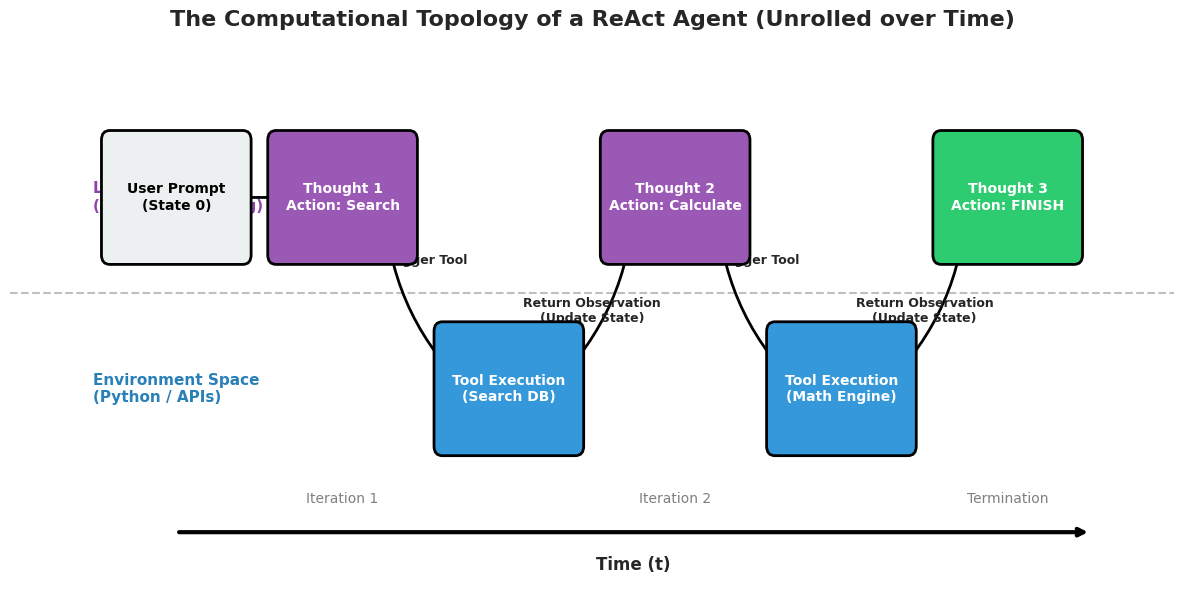

In [3]:
# Visualizing the Unrolled Agentic Topology over Time
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("The Computational Topology of a ReAct Agent (Unrolled over Time)", fontsize=16, fontweight='bold')

ax.axis('off')

# Graph coordinates
y_llm = 4
y_env = 2
x_coords = [1, 3, 5, 7, 9, 11]

# Draw horizontal boundary lines to separate the LLM space from the Environment space
ax.axhline(y=3, color='gray', linestyle='--', alpha=0.5)
ax.text(0, 4, "LLM Space\n(Policy / Reasoning)", fontsize=11, fontweight='bold', va='center', color='#8e44ad')
ax.text(0, 2, "Environment Space\n(Python / APIs)", fontsize=11, fontweight='bold', va='center', color='#2980b9')

# Define Nodes
nodes = [
    (x_coords[0], y_llm, "User Prompt\n(State 0)", "#ecf0f1", "black"),
    (x_coords[1], y_llm, "Thought 1\nAction: Search", "#9b59b6", "white"),
    (x_coords[2], y_env, "Tool Execution\n(Search DB)", "#3498db", "white"),
    (x_coords[3], y_llm, "Thought 2\nAction: Calculate", "#9b59b6", "white"),
    (x_coords[4], y_env, "Tool Execution\n(Math Engine)", "#3498db", "white"),
    (x_coords[5], y_llm, "Thought 3\nAction: FINISH", "#2ecc71", "white")
]

# Draw Edges (The flow of State)
for i in range(len(nodes) - 1):
    x1, y1 = nodes[i][0], nodes[i][1]
    x2, y2 = nodes[i+1][0], nodes[i+1][1]
    
    # Draw curved arrows for cross-boundary transitions
    connectionstyle = "arc3,rad=0.2" if y1 != y2 else "arc3,rad=0.0"
    ax.annotate("", xy=(x2-0.5, y2), xytext=(x1+0.5, y1),
                arrowprops=dict(arrowstyle="->", color="black", lw=2, connectionstyle=connectionstyle))

    # Label the state transitions
    if y1 == y_llm and y2 == y_env:
        ax.text((x1+x2)/2, (y1+y2)/2 + 0.3, "Trigger Tool", ha='center', fontsize=9, fontweight='bold')
    elif y1 == y_env and y2 == y_llm:
        ax.text((x1+x2)/2, (y1+y2)/2 - 0.3, "Return Observation\n(Update State)", ha='center', fontsize=9, fontweight='bold')

# Draw Nodes
for x, y, label, color, text_color in nodes:
    box = patches.FancyBboxPatch((x-0.8, y-0.6), 1.6, 1.2, boxstyle="round,pad=0.1", 
                                 linewidth=2, edgecolor='black', facecolor=color, zorder=3)
    ax.add_patch(box)
    ax.text(x, y, label, ha='center', va='center', fontsize=10, fontweight='bold', color=text_color, zorder=4)

# Draw Time Axis
ax.annotate("", xy=(12, 0.5), xytext=(1, 0.5), arrowprops=dict(arrowstyle="->", color="black", lw=3))
ax.text(6.5, 0.1, "Time (t)", ha='center', fontsize=12, fontweight='bold')
ax.text(3, 0.8, "Iteration 1", ha='center', fontsize=10, color='gray')
ax.text(7, 0.8, "Iteration 2", ha='center', fontsize=10, color='gray')
ax.text(11, 0.8, "Termination", ha='center', fontsize=10, color='gray')

plt.xlim(-1, 13)
plt.ylim(0, 5.5)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of the difference between a Linear Pipeline (DAG) and an Agentic Workflow like **Cooking a Meal**:

* **Linear Pipeline (The Factory Conveyor Belt)**: The ingredients are dumped onto a belt. Machine A chops them. Machine B cooks them for exactly 10 minutes at 400 degrees. Machine C plates them. If the oven is accidentally set to 800 degrees, Machine B doesn't care; it cooks the food for 10 minutes anyway. The pipeline outputs a pile of ashes (Pipeline Failure). It has no ability to observe or adapt.
* **Agentic Workflow (The Master Chef)**: The Chef (The LLM) looks at the ingredients (State). They think, *"I need to chop these first"* (Thought), and they chop them (Action). They put them in the oven. After 5 minutes, they open the oven and look at the food (Observation). They think, *"The oven is too hot, the edges are burning. I need to lower the temperature"* (Thought). They turn the dial down (Action). They check again (Observation). They think, *"It is perfectly cooked, I am done"* (Thought -> FINISH).

The Agent dynamically altered its computational path based on the real-world observations it received from its environment.